# Biais et variance - KMAXPP05

## Configuration du notebook

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output

## Fonctions

In [17]:
def creer_echantillon(n, sigma_irréductible=5., sigma_cache=0., biais=0., coeff_non_lin=0.):
    # Variable explicative observée
    X = np.random.normal(185., 10., (n, 1))
    
    # Variable cachée (pour illustrer l'erreur de Bayes)
    Z = np.random.normal(0, sigma_cache, (n, 1)) 
    
    # Bruit avec biais systémique (pour illustrer la violation de la condition d'exogénéité)
    epsilon = np.random.normal(biais, sigma_irréductible, (n, 1))
    
    # Y dépend de tout, mais le modèle ne verra que X ;)
    Y = -80. + X + Z + epsilon

    # On rajoute un terme non-linéaire (fictif, c'est juste pour illustrer l'erreur d'approximation)
    Xc = (X - 185.) / 10.
    Y += coeff_non_lin * Xc**3
    return X, Y

In [18]:
def tracer_echantillon(X, Y):
    plt.scatter(X, Y, edgecolor="w", s=100)
    plt.xlabel("taille [cm]")
    plt.ylabel("poids [kg]")

In [19]:
def tracer_modele(X=None, Y=None, beta=None, true_beta=None, ci=False):
    Xi = np.linspace(160., 210., 1000).reshape(-1, 1)
    if np.ndim(beta) == 3:
        degres = beta.shape[1] - 1
    elif np.ndim(beta) == 2:
        degres = beta.shape[0] - 1
    Xi_tilde = phi(Xi, degres=degres)
    Yi_hat = Xi_tilde @ beta
    if X is not None and Y is not None:
        plt.scatter(X, Y, edgecolor="w", s=100, zorder=10, label="Données")
    if np.ndim(Yi_hat) == 2:
        plt.plot(Xi, Yi_hat, label=r"$\hat{f}$")
    elif np.ndim(Yi_hat) == 3:
        if not ci:
            for i in range(Yi_hat.shape[0]):
                plt.plot(Xi, Yi_hat[i,:,:], color="k", alpha=0.1)
        else:
            mean = Yi_hat.mean(axis=0).ravel()
            std = Yi_hat.std(axis=0).ravel()
            plt.plot(Xi.ravel(), mean, color="k", label=r"$\hat{f}$ moyen")
            plt.fill_between(Xi.ravel(), mean - 1.96 * std, mean + 1.96 * std, color="k", alpha=0.2, label="95% IC")
    if true_beta is not None:
        plt.plot(Xi, phi(Xi, degres=true_beta.shape[0]-1) @ true_beta, color="green", label=r"Fonction vraie $f$")
    # plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
    plt.legend()
    plt.xlabel("taille [cm]")
    plt.ylabel("poids [kg]")
    plt.xlim(160., 210.)
    plt.ylim(60., 160.)

In [20]:
def tracer_biais_variance(beta, true_beta):
    Xi = np.linspace(160., 210., 1000).reshape(-1, 1)
    if np.ndim(beta) == 3:
        degres = beta.shape[1] - 1
    elif np.ndim(beta) == 2:
        degres = beta.shape[0] - 1
    Xi_tilde = phi(Xi, degres=degres)
    Yi_hat = Xi_tilde @ beta
    Y = phi(Xi, degres=true_beta.shape[0] - 1) @ true_beta
    biais = ((Yi_hat - Y).mean(axis=0))**2
    variance = Yi_hat.var(axis=0)
    plt.plot(Xi, biais, label="biais")
    plt.plot(Xi, variance, label="variance")
    plt.legend()
    plt.xlabel("taille [cm]")
    plt.ylabel(r"$\text{poids}^2$ [$\text{kg}^2$]")
    plt.yscale("log")
    plt.xlim(160., 210.)

In [21]:
def phi(X, degres=1):
    # Fonction d'augmentation de l'espace X à l'espace X tilde
    entrees = [np.ones_like(X)]
    for i in range(1, degres+1):
        entrees.append(X**i)
    return np.hstack(entrees)

In [22]:
def moindres_carres(X_tilde, Y):
    # Resolution de la méthode des moindres carrés grâce à une décomposition QR
    # R @ beta = Q.T @ Y
    Q, R = np.linalg.qr(X_tilde)
    beta_hat = sp.linalg.solve_triangular(R, Q.T @ Y, lower=False)
    return beta_hat

In [23]:
def ridge(X_tilde, Y, lbd):
    # Augmentation de X_tilde et Y avec la pénalité ridge
    p = X_tilde.shape[1]
    Ip = np.eye(p)
    Ip[0, 0] = 0
    X_aug = np.vstack((X_tilde, np.sqrt(lbd) * Ip))
    Y_aug = np.vstack((Y, np.zeros((p, 1))))
    # Resolution de la régression Ridge grâce à une décomposition QR
    # R @ beta = Q.T @ Y_aug
    Q, R = np.linalg.qr(X_aug)
    beta_hat = sp.linalg.solve_triangular(R, Q.T @ Y_aug, lower=False)
    return beta_hat

## Exemple

In [24]:
np.random.seed(16)

In [25]:
X, Y = creer_echantillon(n=4)

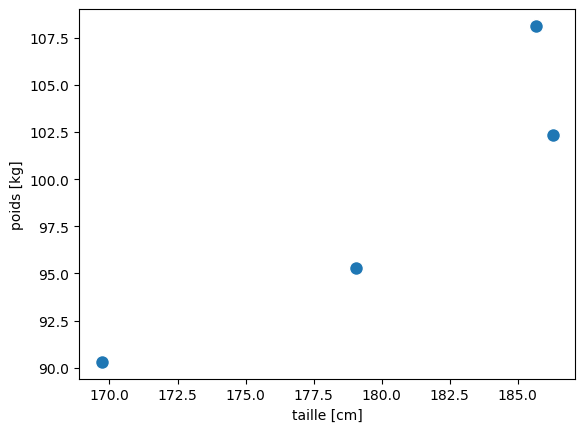

In [26]:
tracer_echantillon(X, Y)

In [27]:
X_tilde = phi(X, degres=1)

In [28]:
beta_hat = moindres_carres(X_tilde, Y)

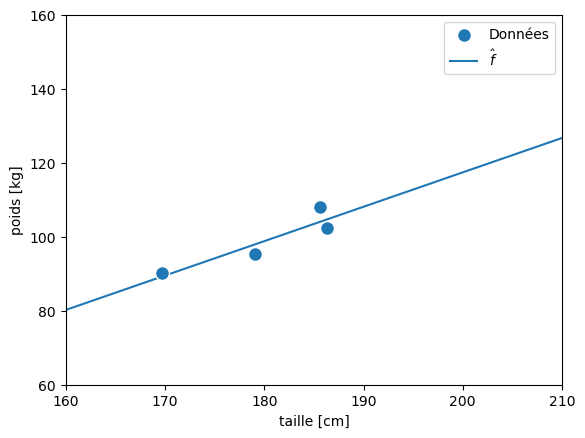

In [29]:
tracer_modele(X, Y, beta_hat)

## Démonstration

In [31]:
style = {'description_width': 'initial'}
layout_slider = widgets.Layout(width='300px')

s_n = widgets.IntSlider(min=4, max=200, step=1, value=4, description='Obs (n)', style=style, layout=layout_slider)
s_d = widgets.IntSlider(min=1, max=10, step=1, value=1, description='Degré (d)', style=style, layout=layout_slider)
s_lbd = widgets.FloatLogSlider(value=0, base=10, min=-4, max=4, step=1, description=r'$\lambda$', style=style, layout=layout_slider)
s_ci = widgets.Checkbox(value=False, description='Afficher IC 95%', indent=False)
s_exo = widgets.Checkbox(value=True, description='Exogénéité active', indent=False)
s_bayes = widgets.FloatSlider(min=0, max=10, step=0.1, value=0, description='Var. Cachée (Bayes)', style=style, layout=layout_slider)
s_nonlin = widgets.Checkbox(value=False, description='Non-linéarité', indent=False)

out = widgets.Output(layout=widgets.Layout(height='550px', border='1px solid #ddd'))

def demo_interractive(n, d, lbd, ci, exogeneity, bayes_sigma, non_lineaire):
    with out:
        clear_output(wait=True)  
        np.random.seed(42)
        m = 100
        if non_lineaire:
            true_beta = np.array([[-6411.625], [103.675], [-0.555], [0.001]])
        else:
            true_beta = np.array([[-80.], [1.]])
        biais_systémique = 0.0 if exogeneity else 15.0
        non_lineaire = 0.0 if not non_lineaire else 1.0
        
        beta_hat_arr = []
        for _ in range(m):
            X_sim, Y_sim = creer_echantillon(n, sigma_cache=bayes_sigma, biais=biais_systémique, coeff_non_lin=non_lineaire)
            X_tilde_sim = phi(X_sim, degres=d)
            beta_hat = ridge(X_tilde_sim, Y_sim, lbd)
            beta_hat_arr.append(beta_hat)
        beta_hat_arr = np.array(beta_hat_arr)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        plt.sca(ax1)
        tracer_modele(beta=beta_hat_arr, true_beta=true_beta, ci=ci)
        status = "Exogène" if exogeneity else "Endogène (Biaisé)"
        ax1.set_title(f"Modèles (n={n}, d={d}) - {status}")
        plt.sca(ax2)
        tracer_biais_variance(beta_hat_arr, true_beta)
        ax2.legend()
        ax2.set_title("Décomposition de l'Erreur Totale")        
        plt.tight_layout()
        plt.show()

ui = widgets.VBox([
    widgets.HBox([s_n, s_d, s_lbd], layout=widgets.Layout(justify_content='space-around')),
    widgets.HBox([s_ci, s_exo, s_bayes, s_nonlin], layout=widgets.Layout(justify_content='space-around'))
])

interactive_render = widgets.interactive_output(demo_interractive, 
    {'n': s_n, 'd': s_d, 'lbd': s_lbd, 'ci': s_ci, 'exogeneity': s_exo, 'bayes_sigma': s_bayes, 'non_lineaire': s_nonlin})

display(ui, out)

Output(layout=Layout(border_bottom='1px solid #ddd', border_left='1px solid #ddd', border_right='1px solid #dd…